# Lab 1: Clustering

Author: Adam Jakubowski 193352

## 1. Visualize the Input Data

Dataset: s1
Shape: (5000, 2)
                   0              1
count    5000.000000    5000.000000
mean   514937.556600  494709.292800
std    244465.901926  235840.852969
min     19835.000000   51121.000000
25%    320352.500000  320107.750000
50%    505338.500000  526259.500000
75%    786228.750000  713713.500000
max    961951.000000  970756.000000 

Dataset: birch1
Shape: (100000, 2)
                   0              1
count  100000.000000   100000.00000
mean   495949.168300   495915.70070
std    265760.545078   265692.57357
min      1371.000000        0.00000
25%    265583.750000   265574.00000
50%    496023.000000   494984.50000
75%    726553.000000   726686.50000
max    996108.000000  1000000.00000 

Dataset: n1
Shape: (2250, 2)
                 0            1
count  2250.000000  2250.000000
mean   1287.528889  1235.433333
std     552.010266   311.483507
min     134.000000    87.000000
25%     808.000000  1044.000000
50%    1088.500000  1296.000000
75%    1901.000000  1444.000000

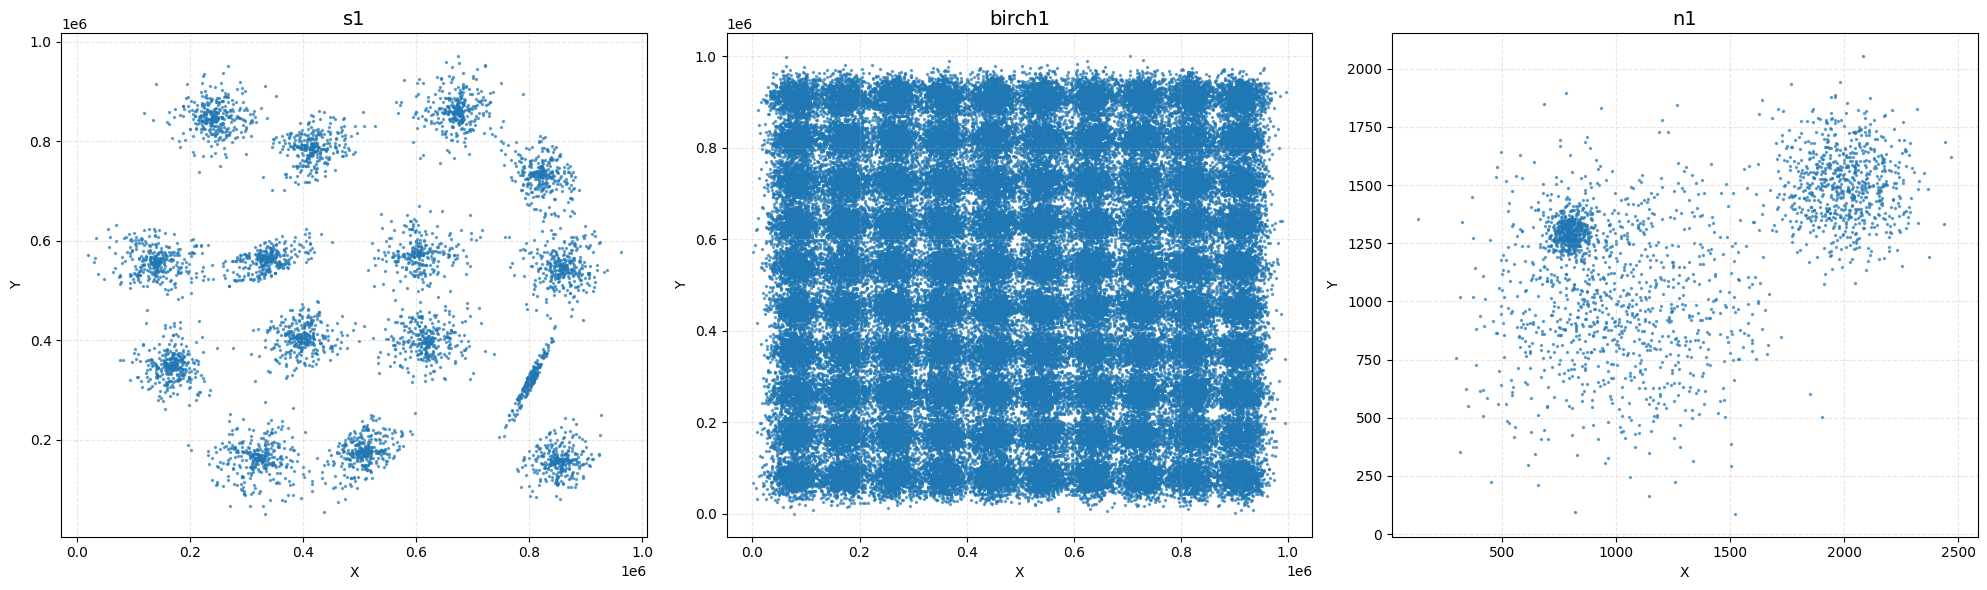

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

loaded_data = {}

datasets_paths = {
    's1': 'data/1_S-sets/s1.txt',
    'birch1': 'data/2_Birch-sets/birch1.txt',
    'n1': 'data/4_Nested-datasets/n1.txt'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, path) in enumerate(datasets_paths.items()):
    df = pd.read_csv(path, sep=r'\s+', header=None)
    loaded_data[name] = df
    
    axes[i].scatter(df[0], df[1], s=2, alpha=0.6, color='tab:blue')
    axes[i].set_title(f"{name}", fontsize=14)
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].grid(True, linestyle='--', alpha=0.3)
    
    print(f"Dataset: {name}")
    print(f"Shape: {df.shape}")
    print(df.describe(), "\n")

plt.tight_layout()
plt.show()

## 2. Dendrogram Analysis

Task: Determine the number of clusters in the dataset using a dendrogram.

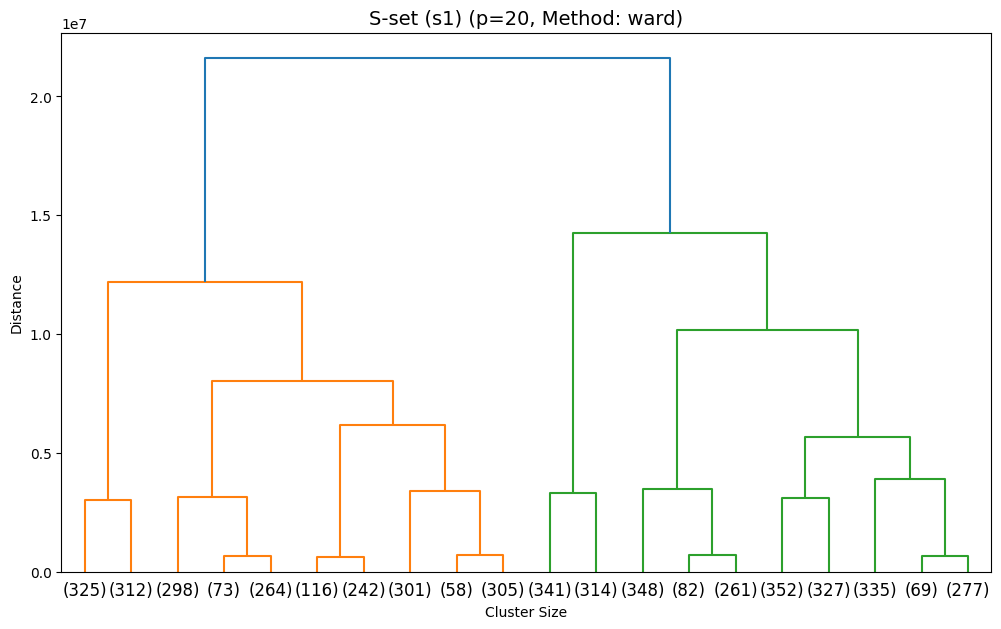

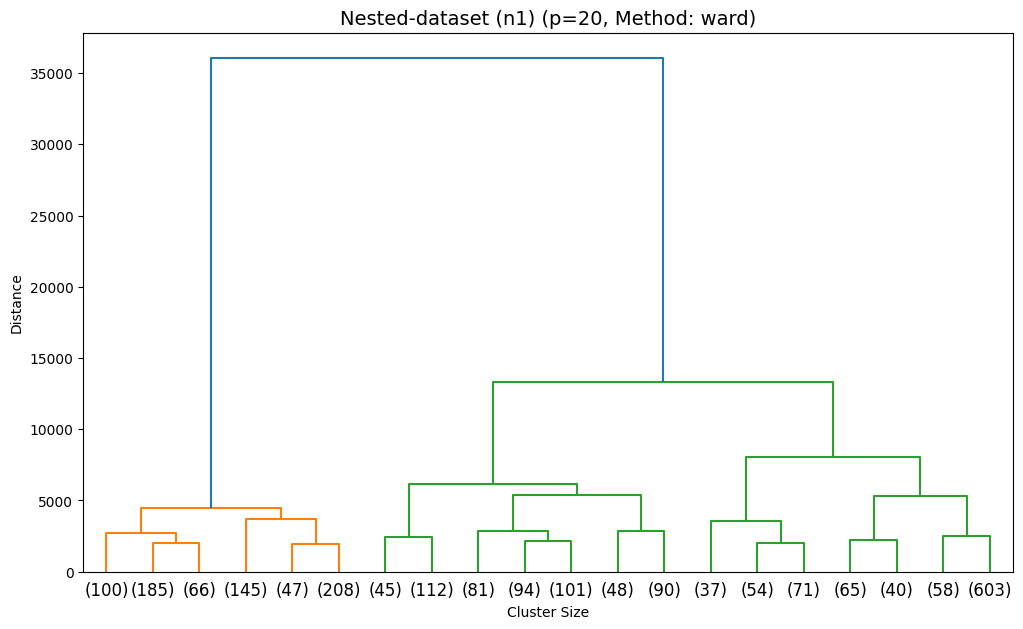

In [15]:
import scipy.cluster.hierarchy as sch

def plot_dendrogram_truncated(dataset, title, truncate_mode='lastp', p=20, method='ward'):
    plt.figure(figsize=(12, 7))
    Z = sch.linkage(dataset, method=method)
    sch.dendrogram(
        Z, 
        truncate_mode=truncate_mode, 
        p=p
    )
    plt.title(f"{title} (p={p}, Method: {method})", fontsize=14)
    plt.xlabel("Cluster Size")
    plt.ylabel(f"Distance")
    plt.show()

plot_dendrogram_truncated(loaded_data['s1'], "S-set (s1)")
plot_dendrogram_truncated(loaded_data['n1'], "Nested-dataset (n1)")

## 3. Compare Linkage Methods

Task: Compare `ward`, `complete`, `average`, and `single` linkage criteria.

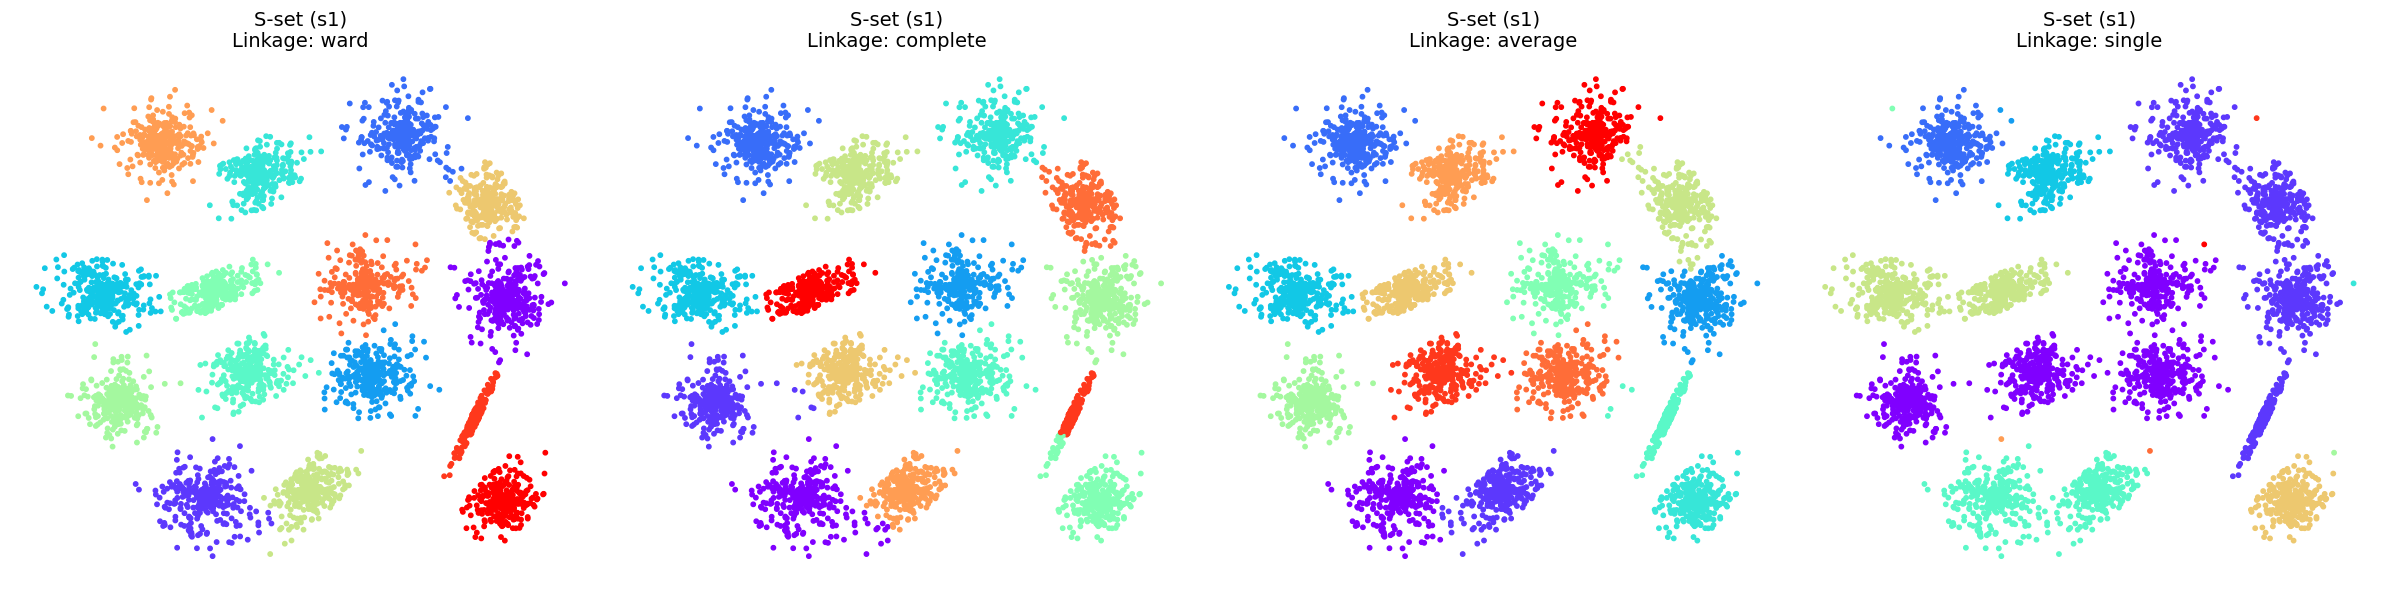

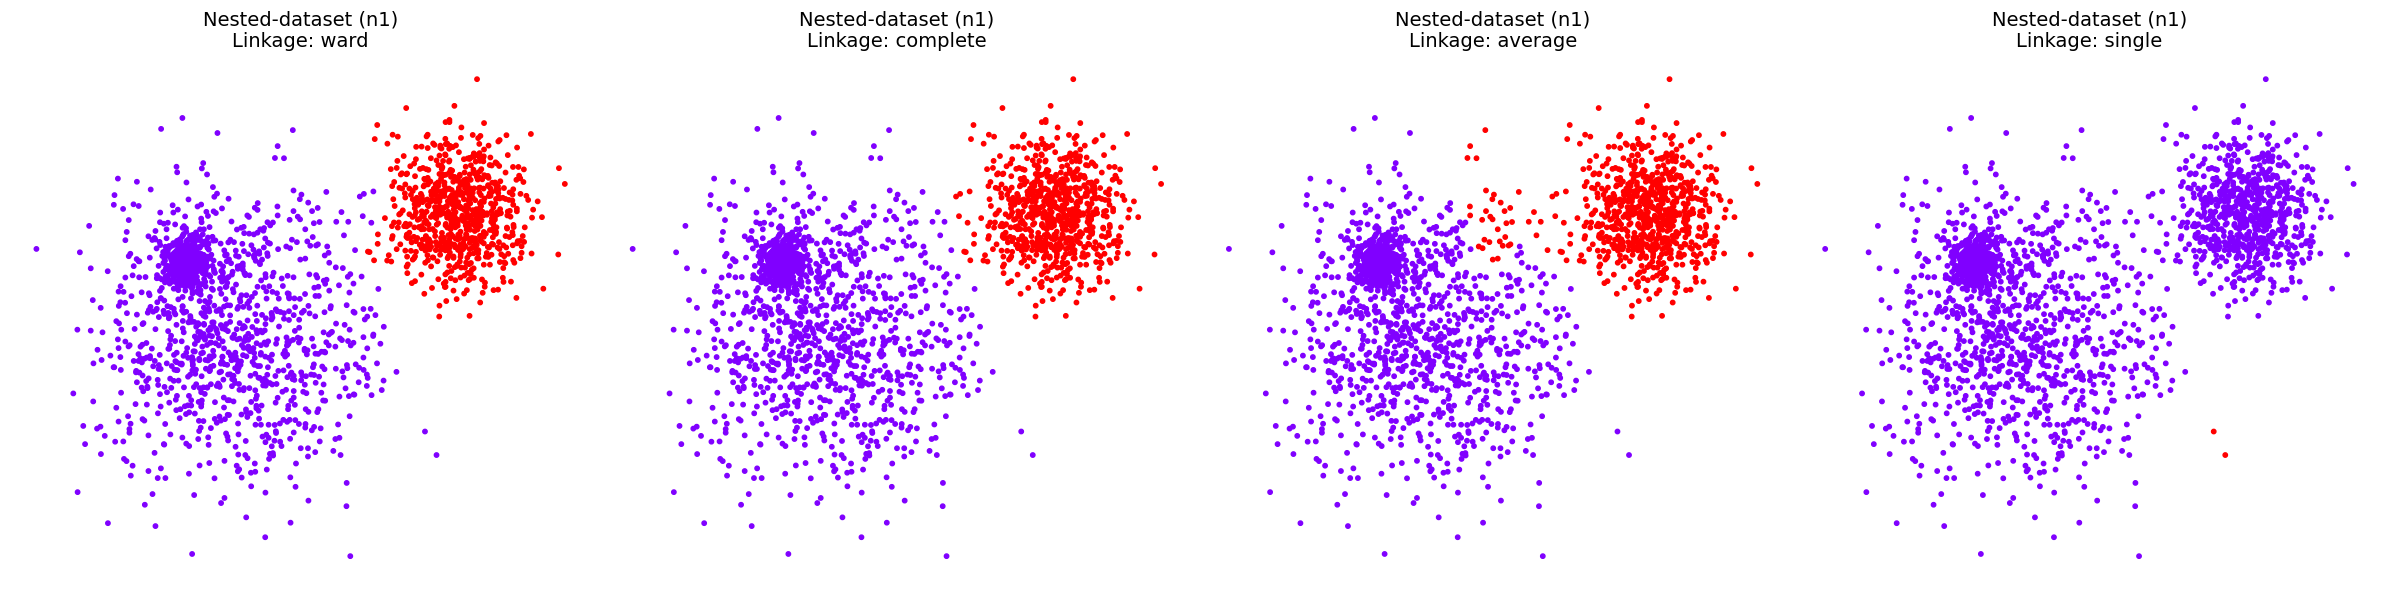

In [21]:
from sklearn.cluster import AgglomerativeClustering

def compare_linkages(dataset, title, n_clusters):
    linkages = ['ward', 'complete', 'average', 'single']
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for i, linkage_type in enumerate(linkages):
        ac = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=linkage_type)
        
        fit_ac = ac.fit_predict(dataset)
        
        axes[i].scatter(dataset.iloc[:, 0], dataset.iloc[:, 1], c=fit_ac, s=10, cmap='rainbow') # I have used rainbow colormap to better viualize cluster for nested dataset
        axes[i].set_title(f"{title}\nLinkage: {linkage_type}", fontsize=14)
        axes[i].axis('off')
       
    plt.tight_layout()
    plt.show()


compare_linkages(loaded_data['s1'], "S-set (s1)", n_clusters=15)
compare_linkages(loaded_data['n1'], "Nested-dataset (n1)", n_clusters=2)
# compare_linkages(loaded_data['birch1'], "Birch-dataset (birch1)", n_clusters=2)


## Summary

`S-set`: 
Ward linkage gives the most balanced and visually coherent clusters. Complete and avarage linkage also perform resonably well, but single-linkage is the least suitable method for this data set because it was tending to create long chains of points that should belong to different clusters (we can observe this in the middle and right of the plot).
For the S-set, the dendrogram shows several clear branches with larger merges near the top, which suggests a moderate number of compact groups. The Ward clustering matches that structure best.

`Nested-set`: 
For the nested data set, the dendrogram shows one large group separated from a smaller dense group. Ward linkage also works best there, but complete and avarage linkage perform very good as well. Unfortunately, single-linkage performs the worst because it links points through thin bridges and merges distant parts too early.

`Birch-set`:
The Birch data set was not clustered with AgglomerativeClustering because it is much larger than the others, so the method could crash the computer because of too much RAM required.